In [27]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
from ASM_utils import AdaptiveSmoothing
import warnings 
import os
import random
warnings.filterwarnings("ignore")

device = torch.device("cpu")
speed = np.load('../data/processed_data/rds/lane1/2024-07-09.npy')
motion = np.load('../data/processed_data/motion/lane1/2024-07-09.npy')
space_size, time_size = speed.shape
speed = torch.tensor(speed, dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # Add batch and channel dimensions
best_model_path = '../logs/calibration/20250607_203336/best_model_lane1.pt'

dx = 0.02                  # distance per cell
dt = 4.0                    # time per cell
kernel_time_window = time_size * dt  # seconds
kernel_space_window = space_size * dx  # same units as dx

In [28]:
# load the best model
best_model_path = '../model/20250607_221107/best_model_lane1.pt'
calibrated_model = torch.load(best_model_path, map_location=device)
calibrated = AdaptiveSmoothing(kernel_time_window,
                          kernel_space_window,
                          dx, dt,
                          init_tau=calibrated_model['tau'],
                          init_delta=calibrated_model['delta'],
                          init_c_cong=calibrated_model['c_cong'],
                          init_c_free=calibrated_model['c_free'],
                          init_v_delta=calibrated_model['v_delta'],
                          init_v_thr=calibrated_model['v_thr']
                          ).to(device)

calibrated.eval()

AdaptiveSmoothing()

In [29]:
original = AdaptiveSmoothing(kernel_time_window,
                          kernel_space_window,
                          dx, dt,
                          init_tau=15.00,
                          init_delta=0.15,
                          init_c_cong=9.30,
                          init_c_free=-43.50,
                          init_v_delta=12.40,
                          init_v_thr=37.30).to(device)
original.eval()

AdaptiveSmoothing()

In [30]:
with torch.no_grad():
    smoothed = calibrated(speed)
    calibrated_asm_speed = smoothed.cpu().numpy().squeeze()

In [31]:
with torch.no_grad():
    original_asm = original(speed)
    original_asm_speed = original_asm.cpu().numpy().squeeze()

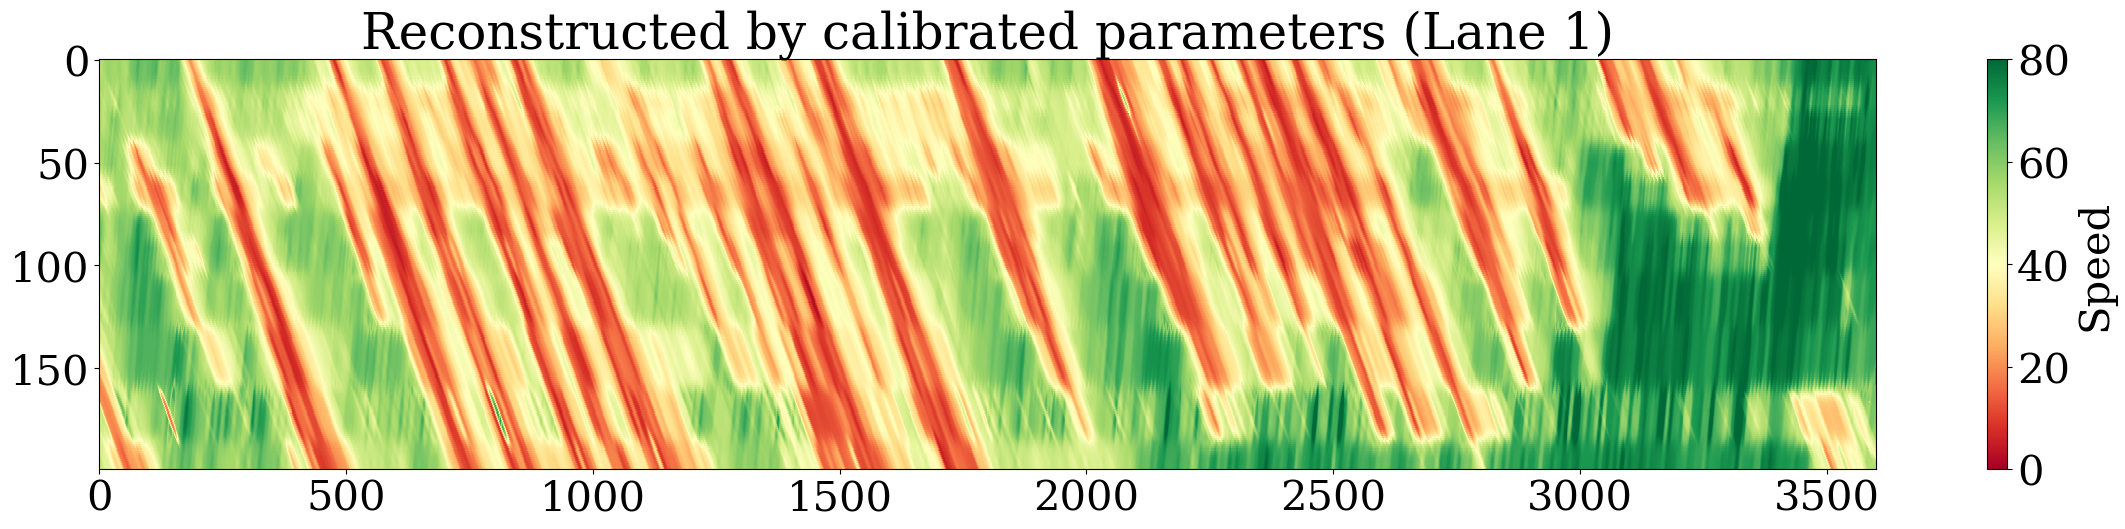

In [32]:
plt.figure(figsize=(24, 6))
plt.rcParams.update({'font.size': 30, 'font.family': 'serif'})
plt.imshow(calibrated_asm_speed, cmap='RdYlGn', interpolation='nearest', origin='lower',vmin=0, vmax=80, aspect='auto')
plt.colorbar(label='Speed')
plt.title('Reconstructed by calibrated parameters (Lane 1)')
plt.tight_layout()
# reverse the y-axis    
plt.gca().invert_yaxis()
import os
if not os.path.exists('../figures/figure4/'):
    os.makedirs('../figures/figure4/')
plt.savefig('../figures/figure4/calibrated_asm_speed.pdf', dpi=300, bbox_inches='tight')
plt.show()

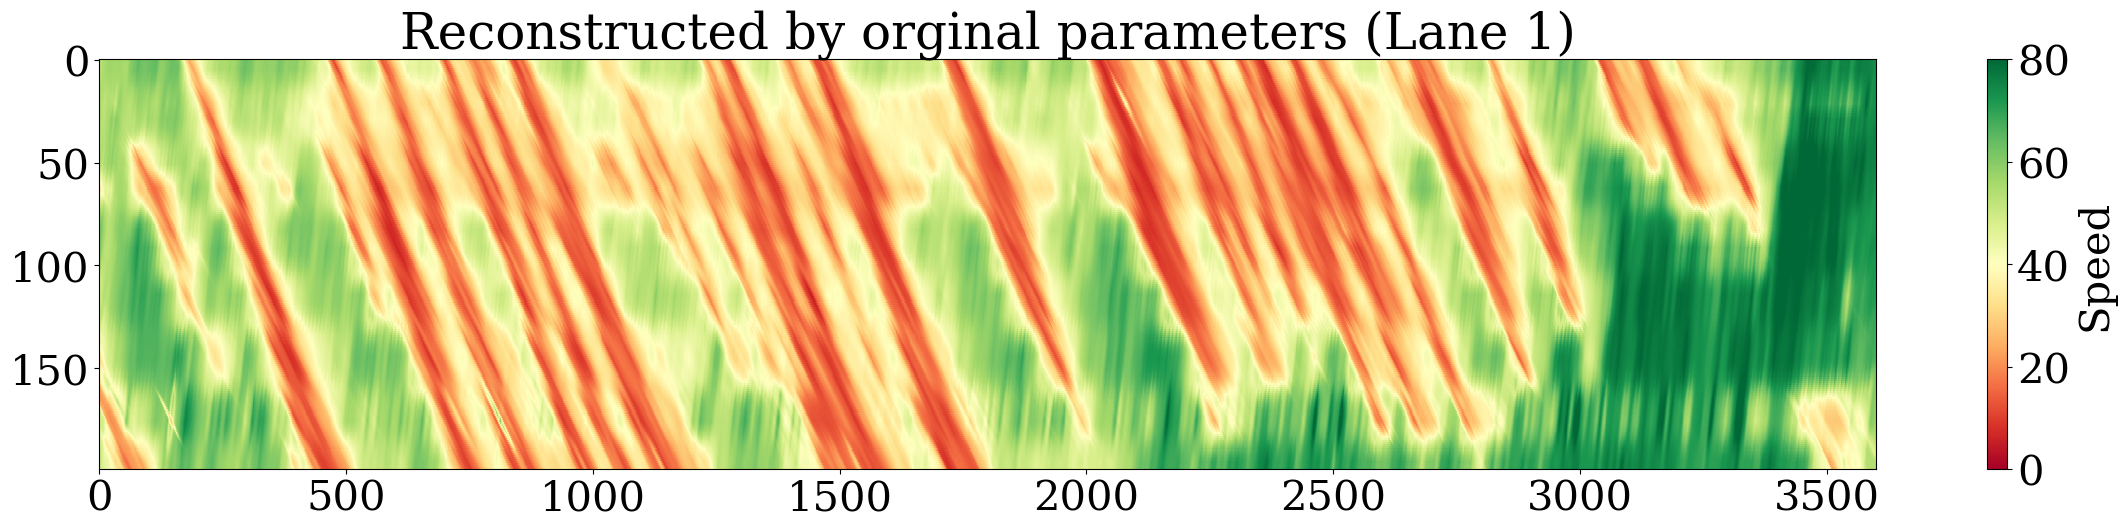

In [33]:
plt.figure(figsize=(24, 6))
plt.rcParams.update({'font.size': 30, 'font.family': 'serif'})
plt.imshow(original_asm_speed, cmap='RdYlGn', interpolation='nearest', origin='lower',vmin=0, vmax=80, aspect='auto')
plt.colorbar(label='Speed')
plt.title('Reconstructed by orginal parameters (Lane 1)')
plt.tight_layout()
# reverse the y-axis    
plt.gca().invert_yaxis()
import os
if not os.path.exists('../figures/figure4/'):
    os.makedirs('../figures/figure4/')
plt.savefig('../figures/figure4/original_asm_speed.pdf', dpi=300, bbox_inches='tight')
plt.show()

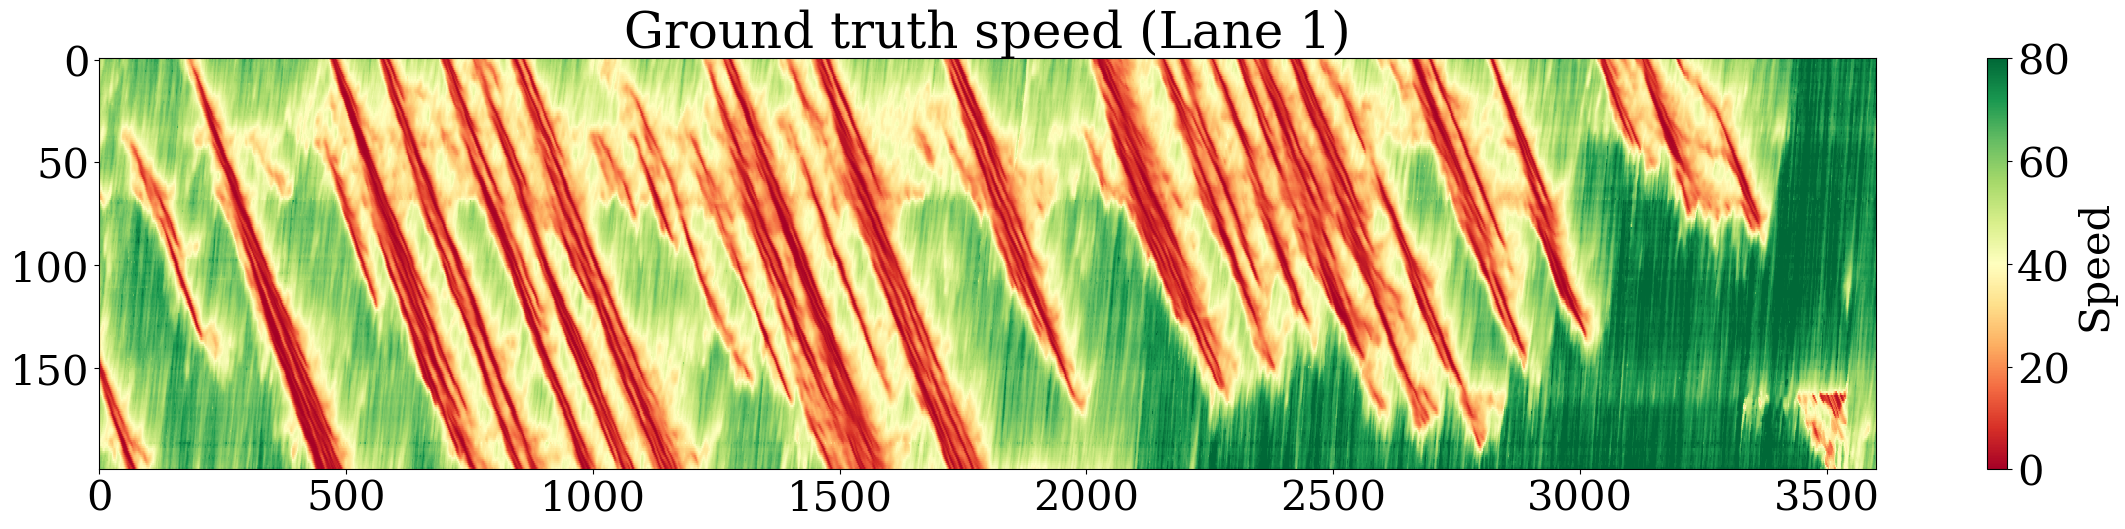

In [34]:
plt.figure(figsize=(24, 6))
plt.rcParams.update({'font.size': 30, 'font.family': 'serif'})
plt.imshow(motion, cmap='RdYlGn', interpolation='nearest', origin='lower',vmin=0, vmax=80, aspect='auto')
plt.colorbar(label='Speed')
plt.title('Ground truth speed (Lane 1)')
plt.tight_layout()
# reverse the y-axis    
plt.gca().invert_yaxis()
import os
if not os.path.exists('../figures/figure4/'):
    os.makedirs('../figures/figure4/')
plt.savefig('../figures/figure4/ground_truth_speed.pdf', dpi=300, bbox_inches='tight')
plt.show()